In [1]:
import sys

sys.path.append("../")

import json
import pickle

import pandas as pd
import seaborn as sns

from qiskit.circuit import ClassicalRegister
from qiskit.quantum_info import hellinger_fidelity
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, SamplerV2 as Sampler

from utils import kullback_leibler_divergence

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme()

In [4]:
simulator = AerSimulator(method="statevector")
pm_simulator = generate_preset_pass_manager(backend=simulator)

In [3]:
with open(file="../../secrets/credentials.json", mode="rt") as f:
    credentials = json.load(f)

In [4]:
service = QiskitRuntimeService(**credentials)

qiskit_runtime_service._discover_account:WARNING:2026-06-06 23:58:39,162: Loading account with the given token. A saved account will not be used.


In [58]:
service.backends()

[<IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>,
 <IBMBackend('ibm_fez')>]

In [114]:
backend = service.backend(name="ibm_marrakesh")
pm = generate_preset_pass_manager(backend=backend, optimization_level=3, seed_transpiler=42)

In [149]:
scenario = "scenarioIII"
opt_lib = "optuna"
optimizer = "CMA-ES"
n_shots = 4096

In [150]:
df_experiments = pd.read_pickle(filepath_or_buffer=f"../experiments/{scenario}/results/{opt_lib}/{optimizer}_n_shots_{n_shots}_experiments.pkl")

In [151]:
df_experiments.sort_values("target_probability_after_training", ascending=False)
best_parameters = df_experiments.sort_values("target_probability_after_training", ascending=False).iloc[0].parameters_after_training

In [152]:
with open(file=f"../experiments/{scenario}/scenario_info.pkl", mode="rb") as f:
    scenario_info = pickle.load(file=f)

In [153]:
qc = scenario_info["circuit"]
optimal_obj_value = scenario_info["optimal_obj_value"]
target = scenario_info["target"]
ising = scenario_info["ising"]
offset = scenario_info["offset"]

# Sampler

In [154]:
qc1 = qc.copy()
bits = ClassicalRegister(size=len(target), name="bits")
qc1.add_register(bits)
qc1.measure(qubit=qc1.qregs[0][ising.num_qubits-len(target):], cbit=bits)

In [155]:
params_mapping = {param: value for param, value in zip(qc1.parameters, best_parameters.values())}
qc1 = qc1.assign_parameters(parameters=params_mapping)
tqc1 = pm_simulator.run(qc1)

In [156]:
counts = simulator.run(circuits=tqc1, shots=4096).result().get_counts()

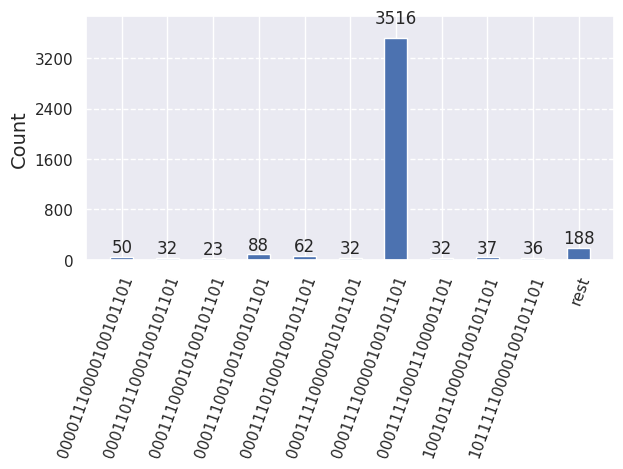

In [157]:
plot_histogram(data=counts, number_to_keep=10)

In [158]:
counts[target]

3516

In [159]:
tqc1 = pm.run(qc1)

In [160]:
options = {"environment": {"job_tags": ["research-dicke-state", optimizer, scenario]}}
sampler = Sampler(mode=backend, options=options)

In [161]:
pubs = [(tqc1,)]
sampler_job = sampler.run(pubs=pubs, shots=n_shots)

In [ ]:
sampler_result = sampler_job.result()
# sampler_job = service.job(job_id=job_id)
# sampler_result = sampler_job.result()

In [21]:
qpu_counts = sampler_result[0].data.bits.get_counts()

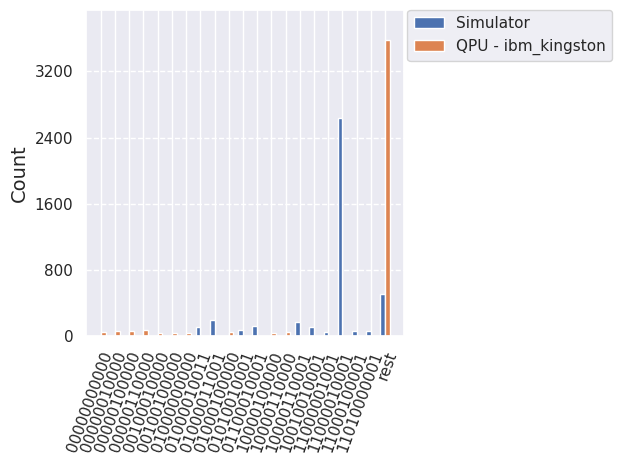

In [22]:
plot_histogram(
    data=[
        counts, 
        qpu_counts
    ],
    legend=["Simulator", "QPU - ibm_kingston"],
    bar_labels=False,
    number_to_keep=10
)

In [23]:
qpu_counts[target]

5

In [29]:
probs_sim = {key: value/4096 for key, value in counts.items()}
probs_qpu = {key: value/4096 for key, value in qpu_counts.items()}

In [30]:
kullback_leibler_divergence(dist_prob1=probs_sim, dist_prob2=probs_qpu)

np.float64(5.015988354034759)

In [32]:
hellinger_fidelity(dist_p=probs_sim, dist_q=probs_qpu)

0.019631512348447108

# Estimator

In [162]:
qc2 = qc.copy()
params_mapping = {param: value for param, value in zip(qc2.parameters, best_parameters.values())}
qc2 = qc2.assign_parameters(parameters=params_mapping)
tqc2 = pm_simulator.run(qc2)

In [110]:
estimator = Estimator(mode=simulator)

In [13]:
pubs = [(tqc2, ising)]
estimator_job = estimator.run(pubs=pubs)

In [14]:
estimator_result = estimator_job.result()

In [17]:
estimator_result[0].data.evs + offset

np.float64(-0.8431865617525338)

In [163]:
options = {"environment": {"job_tags": ["research-dicke-state", optimizer, scenario]}, "resilience_level": 2}
estimator = Estimator(mode=backend, options=options)

In [164]:
tqc2 = pm.run(qc2)
ising_isa = ising.apply_layout(tqc2.layout)

In [165]:
pubs = [(tqc2, ising_isa)]
estimator_job = estimator.run(pubs=pubs)

In [ ]:
estimator_result = estimator_job.result()
# estimator_job = service.job(job_id="d8iala9e8nrc73bi3mdg")
# estimator_result = estimator_job.result()

In [27]:
estimator_result[0].data.evs + offset

np.float64(-0.4406735506007187)